In [1]:
rm(list = ls())
gc(reset = T)

#Original comentado

library(dplyr)
#library(evola2.1)
library(evola.exp)
library(TSA)
library(forecast)


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,653028,34.9,1446577,77.3,653028,34.9
Vcells,1199338,9.2,8388608,64.0,1199338,9.2



Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Adjuntando el paquete: 'TSA'


The following objects are masked from 'package:stats':

    acf, arima


The following object is masked from 'package:utils':

    tar


Registered S3 methods overwritten by 'forecast':
  method       from
  fitted.Arima TSA 
  plot.Arima   TSA 



In [2]:


# Establece directorio
evola.exp::def_user(user = "evazquez", servidor = "165")

# Modelo Original con SARIMA 
##### Solo usa O3 como variable predictora
##### con datos desde el año 2000

In [3]:
# Establecer rango de años
year1 <- 2000
year2 <- as.numeric(format(Sys.Date(), "%Y")) - 1 #Obtener anio anterior
years <- c(2001, 2008, 2012, 2018, 2021)

## Datos horarios de O3
o3.h <- evola.exp::redes_con(start = year1, end = year2)

# Datos horarios de O3 temporales
o3.ht <- evola.exp::redes_con(start = year1, end = year2, temporal = T) %>% 
  dplyr::filter(!date %in% o3.h$date) # Esto es solo para comparar si estan las mismas fechas en bases diferentes
# En este caso comparaba las fechas de validados con temporales


In [16]:

# Junta validados con temporales
# Filtra estaciones transporte de 2018 en adelante
# Transporte se quita desde 2017
o3.h <- rbind(o3.h, o3.ht) %>% 
  dplyr::filter(!(as.numeric(format(date, "%Y")) >= 2017 & id_station %in% c("ACO", "AJU", "INN", "MON", "MPA"))) 


## Maximos diarios
o3.d <- o3.h %>%
  dplyr::group_by(date = as.Date(date)) %>%
  dplyr::summarise(valor = max(valor, na.rm = T))


## Conteo de contingencias por mes y año en temporada de ozono - 15 febrero a 15 junio
o3.temp <- o3.d %>%
  dplyr::filter(format(date, "%m") %in% sprintf("%02d", 2:6),
         !format(date, "%m-%d") %in% paste("02", sprintf("%02d", 1:14), sep = "-"),
         !format(date, "%m-%d") %in% paste("06", 16:30, sep = "-")) %>%
  dplyr::group_by(year = format(date, "%Y"), month = factor(format(date, "%B"), c("febrero", "marzo", "abril", "mayo", "junio"))) %>%
  dplyr::summarise(ndias = sum(valor >= 155))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year and month.
ℹ Output is grouped by year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, month))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


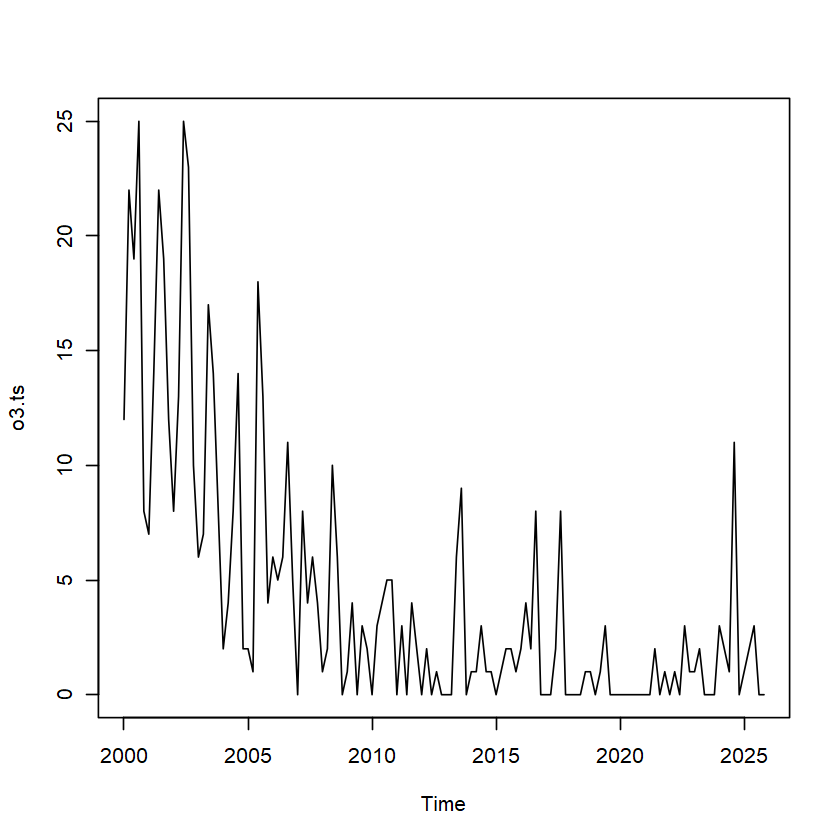

In [5]:
# Serie de tiempo

# Serie para temporada de ozono
o3.ts <- ts(o3.temp$ndias, start = c(year1, 1), end = c(year2, 5), frequency = 5)
plot(o3.ts)


In [17]:
# Modelo sencillo
o3.mod.ts <- auto.arima(o3.ts, seasonal = T)

In [18]:
cat("\n============================\n")
cat("===== RESUMEN DEL MODELO =====\n")
cat("\n============================\n")
summary(o3.mod.ts)



===== RESUMEN DEL MODELO =====



Series: o3.ts 
ARIMA(1,0,1)(2,1,0)[5] 

Coefficients:
         ar1      ma1     sar1     sar2
      0.9895  -0.8704  -0.7193  -0.4189
s.e.  0.0161   0.0597   0.0891   0.0906

sigma^2 = 9.425:  log likelihood = -317.58
AIC=645.16   AICc=645.66   BIC=659.3

Training set error measures:
                     ME     RMSE      MAE MPE MAPE      MASE       ACF1
Training set 0.05426868 2.961826 2.178563 NaN  Inf 0.8617734 -0.0455159



===== RESIDUOS =====


	Ljung-Box test

data:  Residuals from ARIMA(1,0,1)(2,1,0)[5]
Q* = 3.2311, df = 6, p-value = 0.7793

Model df: 4.   Total lags used: 10



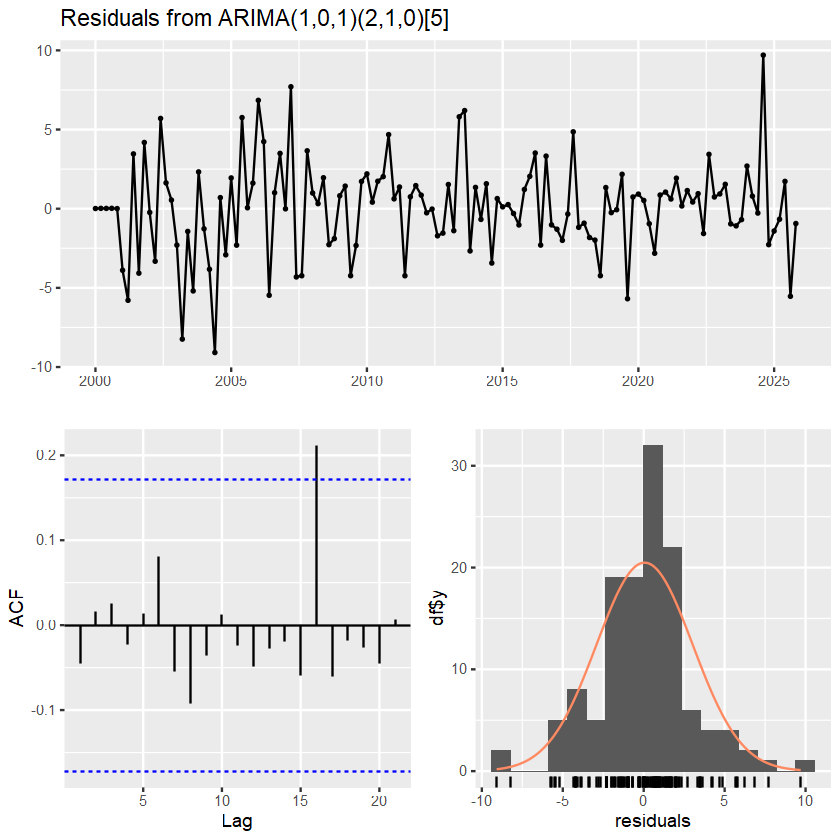

In [19]:
cat("\n============================\n")
cat("\n===== RESIDUOS =====\n")
cat("\n============================\n")
checkresiduals(o3.mod.ts)


In [20]:
cat("\n============================\n")
cat("\n===== INTERVALOS DE CONFIANZA =====\n")
cat("\n============================\n")
confint(o3.mod.ts)




===== INTERVALOS DE CONFIANZA =====



,2.5 %,97.5 %
ar1,0.9578535,1.0211554
ma1,-0.9873837,-0.7534168
sar1,-0.8939507,-0.5445631
sar2,-0.5965171,-0.2413506


In [22]:
cat("\n============================\n")
cat("\n===== METRICAS =====\n")
cat("\n============================\n")
accuracy(o3.mod.ts)



===== METRICAS =====



,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,0.05426868,2.961826,2.178563,NaN,Inf,0.8617734,-0.0455159


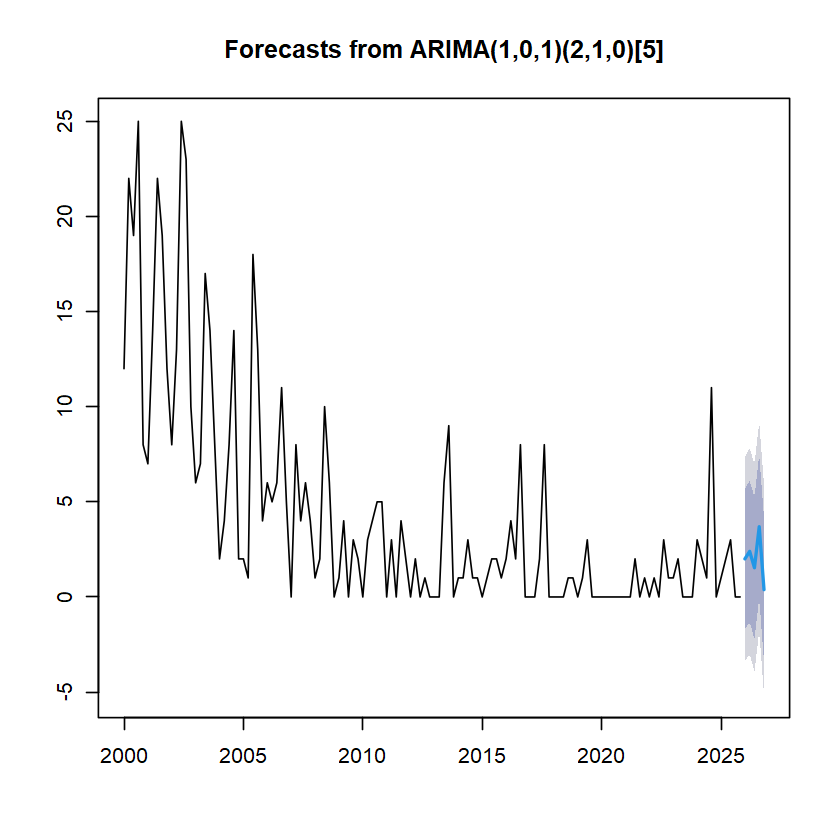

In [23]:
# Se hace el pronostico con el modelo, con intervalo de confianza de 77-92% 
# el argumento "h" es el horizonte de pronostico
# pronostica los proximos 5 periodos (febrero, marzo, abril, mayo, junio)

pronostico <- forecast(o3.mod.ts, h = 5, level = c(77, 92))

## Ajuste del pronostico
if(min(pronostico$mean) < 0){
  aju <- round(min(pronostico$mean))
  pronostico$mean <- round(pronostico$mean) - aju
  pronostico$fitted <- pronostico$fitted - aju
}
plot(pronostico)

## Tabla de pronostico de dias por mes
pron.dias <- data.frame(month = factor(c("febrero","marzo","abril","mayo","junio")),
                        min = pronostico$mean,
                        p_80 = round(pronostico$upper[,1]),
                        p_95 = round(pronostico$upper[,2]))
  



In [24]:
o3.temp <- merge(o3.temp, pron.dias, by = "month")

probs <- o3.temp %>%
  dplyr::filter(year %in% years) %>%
  dplyr::group_by(month) %>%
  dplyr::summarise(prob_80 = sum(ndias <= first(p_80))/n(),
            prob_95 = sum(ndias <= first(p_95))/n())


## Tabla final con el pronostico de dias por mes
tabla.exp <- data.frame(mes = as.character(pron.dias$month),
                        Minimo = as.integer(round(pron.dias$min)),
                        Promedio = as.integer(round(pron.dias$p_80*probs$prob_80)),
                        Maximo = as.integer(round(pron.dias$p_95*probs$prob_95)))

total <- tabla.exp %>% 
  dplyr::summarise(Minimo = sum(Minimo),
                   Promedio = sum(Promedio),
                   Maximo = sum(Maximo)) %>% 
  dplyr::mutate(mes = "Total") %>% 
  dplyr::relocate(mes)

tabla.exp <- rbind(tabla.exp, total)

In [25]:
tabla.exp

mes,Minimo,Promedio,Maximo
<chr>,<int>,<int>,<int>
febrero,2,5,7
marzo,2,5,6
abril,2,3,4
mayo,4,6,7
junio,0,3,5
Total,10,22,29


# Modelo SARIMAX 
###### con O3, WSP y TMP 
###### datos desde 1989

In [26]:
#modelando desde 2010 corrige errores de meses problematicos
## Year selection
year1 <- 1989
# DEsde 1989 capta mejor estacionalidad y temporalidad pero mayor MAE y RMSE

#  con 1989 me salen 13 dias en promedio

# con año 2000 el promedio aumento a 14 dias

# con año 2010 el promeidio subio 1 21 dias


year2 <- as.numeric(format(Sys.Date(), "%Y")) -1
years <- c(2001, 2008, 2012, 2018, 2021)

In [27]:
# Temperatura y vientos horarios

temperatura <- evola.exp::redes_con(
  red = "redmet",
  parametros = "tmp",
  start = year1,
  end = year2
)




v_viento <- evola.exp::redes_con(
  red = "redmet",
  parametros = "wsp",
  start = year1,
  end = year2
)

In [28]:
# Promedio diario de temperatura
tmp.d <- temperatura %>%
  mutate(date = as.Date(date)) %>%
  group_by(date) %>%
  summarise(
    tmp = mean(valor, na.rm = TRUE),
    .groups = "drop"
  )


wsp.d <- v_viento %>%
  mutate(date = as.Date(date)) %>%
  group_by(date) %>%
  summarise(
    wsp = mean(valor, na.rm = TRUE),
    .groups = "drop"
  )


In [29]:
# Datos horarios O3 (2017 sin transporte)

o3.h <- evola.exp::redes_con(start = year1, end = year2)

o3.ht <- evola.exp::redes_con(
  start = year1,
  end = year2,
  temporal = TRUE
) %>%
  dplyr::filter(!date %in% o3.h$date)

o3.h <- rbind(o3.h, o3.ht) %>%
  dplyr::filter(
    !(as.numeric(format(date, "%Y")) >= 2017 &
        id_station %in% c("ACO", "AJU", "INN", "MON", "MPA"))
  )


In [30]:
# Maximos diarios O3 
o3.d <- o3.h %>%
  mutate(date = as.Date(date)) %>%
  group_by(date) %>%
  summarise(
    valor = if (all(is.na(valor))) {
      NA_real_
    } else {
      max(valor, na.rm = TRUE)
    },
    .groups = "drop"
  )

In [31]:
# Unir O3 diario con temperatura diaria

base.d <- o3.d %>%
  left_join(tmp.d, by = "date") %>%
  left_join(wsp.d, by = "date") 


In [32]:
# Obtener numero de dias >= 155 temporada de O3
# Promedios de wsp y tmp

o3.temp <- base.d %>%
  dplyr::filter(
    format(date, "%m") %in% sprintf("%02d", 2:6),
    !format(date, "%m-%d") %in% paste("02", sprintf("%02d", 1:14), sep = "-"),
    !format(date, "%m-%d") %in% paste("06", 16:30, sep = "-")
  ) %>%
  dplyr::group_by(
    year = as.numeric(format(date, "%Y")),
    month = as.numeric(format(date, "%m"))
  ) %>%
  dplyr::summarise(
    ndias = sum(valor >= 155),
    wsp_prom = mean(wsp, na.rm = TRUE),
    tmp_prom = mean(tmp, na.rm = TRUE),
    .groups = "drop"
  ) 

In [33]:
# Obtener serie de tiempo
o3.ts <- ts(
  o3.temp$ndias,
  start = c(min(o3.temp$year), min(o3.temp$month)),
  frequency = 5
)

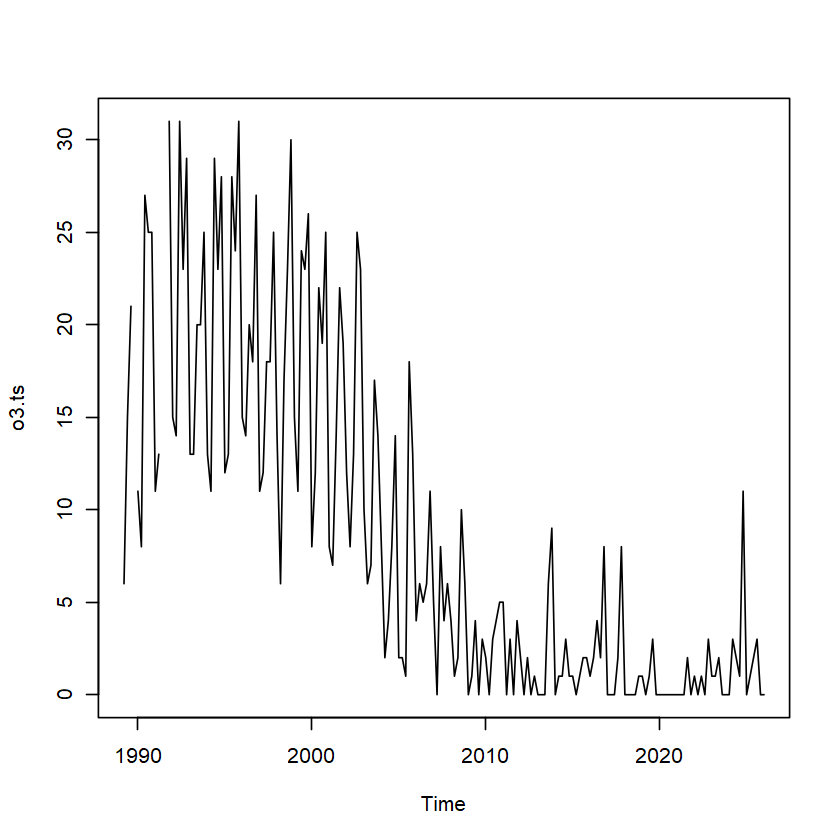

In [34]:
# modelo entrenamiento

xreg_train <- as.matrix(o3.temp[, c("tmp_prom", "wsp_prom")])

plot(o3.ts)


In [36]:
# Modelo ARIMAX
# Usa variables externas (WSP y TMP)
o3.mod.ts <- auto.arima(
  y = o3.ts,
  xreg = xreg_train,
  seasonal = TRUE, #Temporal
  stepwise = FALSE, #busqueda exhaustiva de modelos
  approximation = FALSE # Calcula likelihood exacta
)



In [37]:
cat("\n============================\n")
cat("===== RESUMEN DEL MODELO =====\n")
cat("\n============================\n")
summary(o3.mod.ts)


===== RESUMEN DEL MODELO =====



Series: o3.ts 
Regression with ARIMA(1,0,1)(0,1,1)[5] errors 

Coefficients:
         ar1      ma1     sma1  tmp_prom  wsp_prom
      0.9539  -0.7406  -0.6337    0.8728   -5.3521
s.e.  0.0347   0.0815   0.0626    0.1988    1.2127

sigma^2 = 9.124:  log likelihood = -445.72
AIC=903.44   AICc=903.92   BIC=922.59

Training set error measures:
                     ME     RMSE      MAE MPE MAPE      MASE       ACF1
Training set -0.2496268 2.936433 2.270618 NaN  Inf 0.8243947 0.01894472



===== RESIDUOS =====


	Ljung-Box test

data:  Residuals from Regression with ARIMA(1,0,1)(0,1,1)[5] errors
Q* = 3.1711, df = 7, p-value = 0.8687

Model df: 3.   Total lags used: 10



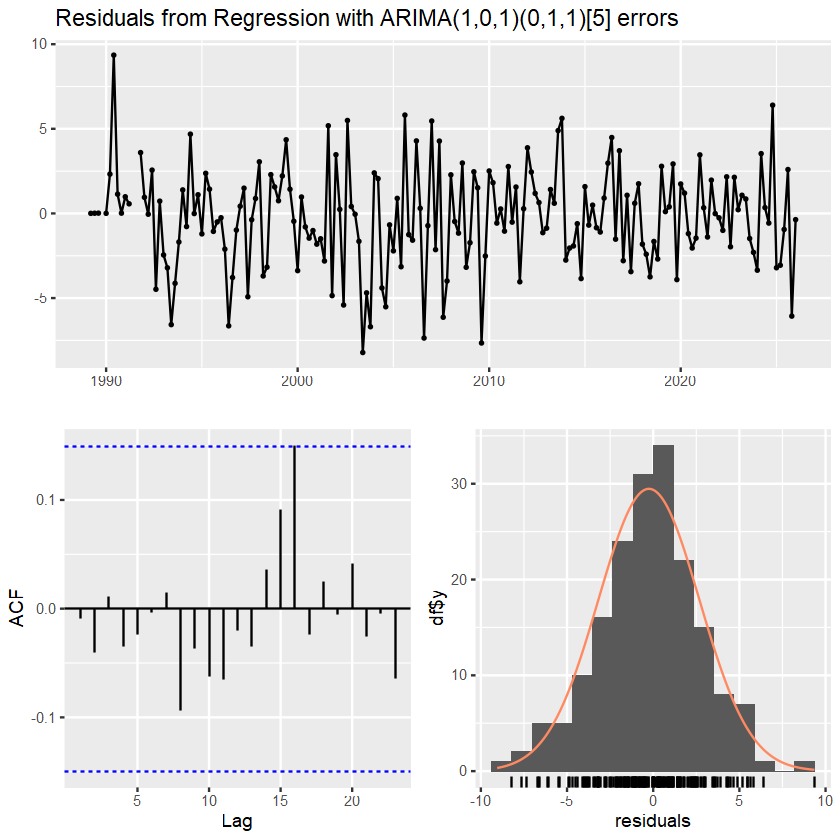

In [38]:
cat("\n============================\n")
cat("\n===== RESIDUOS =====\n")
cat("\n============================\n")
checkresiduals(o3.mod.ts)

In [39]:
cat("\n============================\n")
cat("\n===== INTERVALOS DE CONFIANZA =====\n")
cat("\n============================\n")
confint(o3.mod.ts)



===== INTERVALOS DE CONFIANZA =====



,2.5 %,97.5 %
ar1,0.8859473,1.0218320
ma1,-0.9003893,-0.5808530
sma1,-0.7563642,-0.5109621
tmp_prom,0.4831852,1.2623584
wsp_prom,-7.7289380,-2.9752330


In [40]:
cat("\n============================\n")
cat("\n===== METRICAS =====\n")
cat("\n============================\n")
accuracy(o3.mod.ts)



===== METRICAS =====



,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,-0.2496268,2.936433,2.270618,NaN,Inf,0.8243947,0.01894472


In [41]:
# Promedios de tmp y wsp para pronosticos

clima_wsp <- o3.temp %>%
  group_by(month) %>%
  summarise(
    wsp_clim = mean(wsp_prom, na.rm = TRUE),
    .groups = "drop"
  )

clima_tmp <- o3.temp %>%
  group_by(month) %>%
  summarise(
    tmp_clim = mean(tmp_prom, na.rm = TRUE),
    .groups = "drop"
  )


xreg_fut <- clima_tmp %>%
  left_join(clima_wsp, by = "month") %>%
  arrange(month)

xreg_fut <- as.matrix(xreg_fut[, c("tmp_clim", "wsp_clim")])



Warning message in forecast.forecast_ARIMA(o3.mod.ts, xreg = xreg_fut, h = 5, level = c(77, :
"xreg contains different column names from the xreg used in training. Please check that the regressors are in the same order."


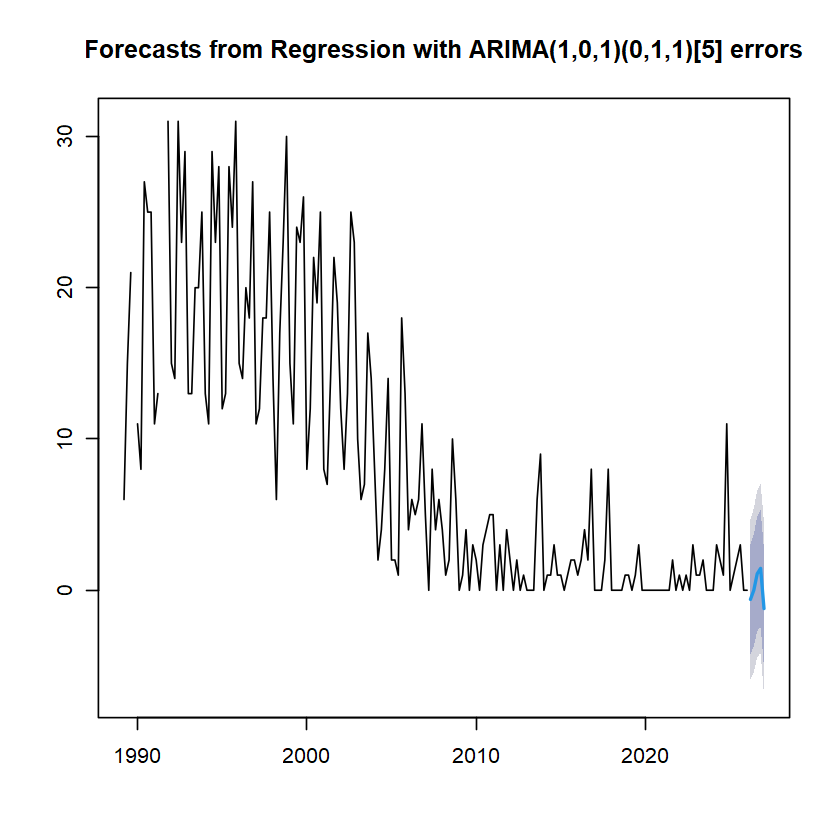

In [42]:
# Pronostico con ARIMAX

pronostico <- forecast(
  o3.mod.ts,
  xreg = xreg_fut,
  h = 5,
  level = c(77, 92) # probabilidad de que el valor real este entre esos intervalos de confianza
  # 77-92 FUNCIONA BIEN 
  # level = c(80, 95) 
)


plot(pronostico)



pron_tab <- pronostico

pron_tab$mean  <- pmax(as.numeric(pron_tab$mean), 0)
pron_tab$lower <- apply(pron_tab$lower, 2, function(x) pmax(as.numeric(x), 0))
pron_tab$upper <- apply(pron_tab$upper, 2, function(x) pmax(as.numeric(x), 0))

In [43]:
# Tabla de pronostico

pron.dias <- data.frame(
  month = 2:6,
  mes = c("febrero","marzo","abril","mayo","junio"),
  min = as.numeric(pronostico$mean),
  p_80 = round(as.numeric(pron_tab$upper[, 1])),
  p_95 = round(as.numeric(pron_tab$upper[, 2]))
) %>%
  dplyr::filter(month %in% 2:6)

In [44]:
# Probabilidades con años seleccionados
o3.temp2 <- merge(o3.temp, pron.dias, by = "month")

probs <- o3.temp2 %>%
  dplyr::filter(year %in% years) %>%
  dplyr::group_by(month) %>%
  dplyr::summarise(
    prob_80 = sum(ndias <= first(p_80)) / n(),
    prob_95 = sum(ndias <= first(p_95)) / n(),
    .groups = "drop"
  )


In [45]:
# Tabla Final

tabla.exp <- data.frame(
  mes = pron.dias$mes,
  Minimo = pmax(as.integer(round(pron.dias$min)), 0),
  Promedio = as.integer(round(pron.dias$p_80 * probs$prob_80)),
  Maximo = as.integer(round(pron.dias$p_95 * probs$prob_95))
)

total <- tabla.exp %>%
  dplyr::summarise(
    Minimo = sum(Minimo),
    Promedio = sum(Promedio),
    Maximo = sum(Maximo)
  ) %>%
  dplyr::mutate(mes = "Total") %>%
  dplyr::relocate(mes)

tabla.exp <- rbind(tabla.exp, total)

View(tabla.exp)

mes,Minimo,Promedio,Maximo
<chr>,<dbl>,<int>,<int>
febrero,0,2,4
marzo,0,3,4
abril,1,3,4
mayo,1,3,6
junio,0,2,3
Total,2,13,21
